In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [73]:
df = pd.read_csv(r"C:\Users\MSI\Desktop\TSE_Risk_Return-Analysis\data\MP1_Data.csv")
df

,Unnamed: 0,Low,High,Yesterday,First,insCode,Date,Close,AdjClose,Volume,Value,jDate,stock_name
0,0,3519.0,3519.0,3417.0,3519.0,63363116407864462,2026-05-23,3519.0,3519.0,249737.0,8.788245e+08,1405-03-02,لابسا
1,1,3417.0,3417.0,3318.0,3417.0,63363116407864462,2026-05-20,3417.0,3417.0,1440266.0,4.921389e+09,1405-02-30,لابسا
2,2,3158.0,3352.0,3255.0,3158.0,63363116407864462,2026-05-19,3318.0,3352.0,966452.0,3.206899e+09,1405-02-29,لابسا
3,3,0.0,0.0,3255.0,0.0,63363116407864462,2026-05-18,3255.0,3218.0,0.0,0.000000e+00,1405-02-28,لابسا
4,4,0.0,0.0,3255.0,0.0,63363116407864462,2026-05-17,3255.0,3218.0,0.0,0.000000e+00,1405-02-27,لابسا
...,...,...,...,...,...,...,...,...,...,...,...,...,...
121091,121091,14952.0,15653.0,14908.0,15653.0,59921975187856916,2004-07-24,14952.0,14952.0,500.0,7.825799e+06,1383-05-03,غشاذر
121092,121092,14908.0,14908.0,14199.0,14908.0,59921975187856916,2004-07-20,14908.0,14908.0,38720.0,5.772378e+08,1383-04-30,غشاذر
121093,121093,14199.0,14819.0,14114.0,14819.0,59921975187856916,2004-07-19,14199.0,14199.0,1000.0,1.481838e+07,1383-04-29,غشاذر
121094,121094,14114.0,14700.0,14000.0,14700.0,59921975187856916,2004-07-18,14114.0,14114.0,1359.0,1.997671e+07,1383-04-28,غشاذر


1️⃣) In this 5-year period, calculate the monthly return of each company. Identify which company had the highest and which had the lowest return overall in these 5 years, as well as
for each individual month.

In [74]:
df = df.drop(columns=['Unnamed: 0'])

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(['insCode', 'Date'])


In [75]:
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 121096 entries, 41400 to 17576
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Low         121096 non-null  float64       
 1   High        121096 non-null  float64       
 2   Yesterday   121096 non-null  float64       
 3   First       121096 non-null  float64       
 4   insCode     121096 non-null  int64         
 5   Date        121096 non-null  datetime64[ns]
 6   Close       121096 non-null  float64       
 7   AdjClose    121096 non-null  float64       
 8   Volume      121096 non-null  float64       
 9   Value       121096 non-null  float64       
 10  jDate       121096 non-null  object        
 11  stock_name  121096 non-null  object        
dtypes: datetime64[ns](1), float64(8), int64(1), object(2)
memory usage: 12.0+ MB
None


,Low,High,Yesterday,First,insCode,Date,Close,AdjClose,Volume,Value,jDate,stock_name
41400,1650.0,1763.0,0.0,1763.0,1358190916156744,2004-04-26,1715.0,1715.0,491000.0,842492065.0,1383-02-07,وآذر
41399,1800.0,1800.0,1715.0,1800.0,1358190916156744,2004-04-28,1800.0,1800.0,102100.0,183780000.0,1383-02-09,وآذر
41398,1890.0,1890.0,1800.0,1890.0,1358190916156744,2004-05-01,1890.0,1890.0,117099.0,221317110.0,1383-02-12,وآذر
41397,1984.0,1984.0,1890.0,1984.0,1358190916156744,2004-05-02,1984.0,1984.0,352262.0,698887808.0,1383-02-13,وآذر
41396,2083.0,2083.0,1984.0,2083.0,1358190916156744,2004-05-03,2083.0,2083.0,252162.0,525253446.0,1383-02-14,وآذر


Which Price? adjClose or Close? adjusted  
به دلیل افزایش سرمایه ها و سود نقدی.

In [76]:
df['AdjClose'].describe()


count    121096.000000
mean      10235.564007
std       25224.096127
min         355.000000
25%        1787.000000
50%        3713.500000
75%        8328.500000
max      379450.000000
Name: AdjClose, dtype: float64

In [77]:
(df['AdjClose']==0).sum()
#از این جهت داده ما تمیز است

np.int64(0)

داده های سال 1400 به بعد رو میخواهیم

In [78]:
df = df[df['jDate'] >= '1400-01-01']

In [79]:
df[['jDate', 'Date']].head()

,jDate,Date
37879,1400-01-07,2021-03-27
37878,1400-01-08,2021-03-28
37877,1400-01-10,2021-03-30
37876,1400-01-11,2021-03-31
37875,1400-01-14,2021-04-03


In [80]:
df['jDate'].min(), df['jDate'].max()
#پس درسته

('1400-01-07', '1405-03-02')

اینجا ما میخوایم از داده های ماهانه برای return استفاده کنیم

In [81]:
monthly_prices = (
    df.groupby(
        ['stock_name', pd.Grouper(key='Date', freq='ME')]
    )['AdjClose']
    .last()
    .reset_index()
)
#اول : براساس سهم دسته بندی کن - دوم: داخل هرسهم براساس ماه گروه بندی کن 
#سوم: از هر گروه فقط ستون ادج کلوز را نگه دار - چهارم :از هر گروه اخرین مقدار را بردار

In [82]:
monthly_prices.head(65)

,stock_name,Date,AdjClose
0,اتكاي,2021-03-31,18497.0
1,اتكاي,2021-04-30,16680.0
2,اتكاي,2021-05-31,13349.0
3,اتكاي,2021-06-30,10283.0
4,اتكاي,2021-07-31,9300.0
...,...,...,...
60,اتكاي,2026-03-31,2205.0
61,اتكاي,2026-04-30,2067.0
62,اتكاي,2026-05-31,2129.0
63,اعتلا,2021-03-31,8680.0


In [83]:
monthly_prices['Monthly_Return'] = (
    monthly_prices
    .groupby('stock_name')['AdjClose']
    .pct_change()
)

In [84]:
monthly_prices.head(15)


,stock_name,Date,AdjClose,Monthly_Return
0,اتكاي,2021-03-31,18497.0,NaN
1,اتكاي,2021-04-30,16680.0,-0.098232
2,اتكاي,2021-05-31,13349.0,-0.199700
3,اتكاي,2021-06-30,10283.0,-0.229680
4,اتكاي,2021-07-31,9300.0,-0.095595
5,اتكاي,2021-08-31,7880.0,-0.152688
6,اتكاي,2021-09-30,10401.0,0.319924
7,اتكاي,2021-10-31,9757.0,-0.061917
8,اتكاي,2021-11-30,10926.0,0.119811
9,اتكاي,2021-12-31,10441.0,-0.044390


دسته بندی کردیم و بازده برای هر سهم را ماهانه بدست اوردیم

In [85]:
monthly_prices = monthly_prices.dropna(subset=['Monthly_Return'])

In [86]:
monthly_prices.head()

,stock_name,Date,AdjClose,Monthly_Return
1,اتكاي,2021-04-30,16680.0,-0.098232
2,اتكاي,2021-05-31,13349.0,-0.199700
3,اتكاي,2021-06-30,10283.0,-0.229680
4,اتكاي,2021-07-31,9300.0,-0.095595
5,اتكاي,2021-08-31,7880.0,-0.152688


NaN هارا حذف کردیم

📌 با روش \
Average Monthly Return \
بازده هرسهم را حساب میکنیم

❌معیار ساده ای برای عملکرد است اما اثر مرکب شدن بازده هارا نشان نمی دهد

In [87]:
average_returns = (
    monthly_prices
    .groupby('stock_name')['Monthly_Return']
    .mean()
    .reset_index()
)
"""

برو داخل monthly_prices

سهم‌ها رو بر اساس stock_name گروه‌بندی کن

از هر گروه فقط ستون Monthly_Return رو بردار

برای هر سهم میانگین Monthly_Return رو حساب کن

نتیجه رو به شکل یک DataFrame تمیز برگردون

"""

'\n\nبرو داخل monthly_prices\n\nسهم\u200cها رو بر اساس stock_name گروه\u200cبندی کن\n\nاز هر گروه فقط ستون Monthly_Return رو بردار\n\nبرای هر سهم میانگین Monthly_Return رو حساب کن\n\nنتیجه رو به شکل یک DataFrame تمیز برگردون\n\n'

In [88]:
average_returns.head(30)

,stock_name,Monthly_Return
0,اتكاي,-0.026889
1,اعتلا,-0.015899
2,بتك,0.032535
3,بهپاك,-0.004232
4,تكنار,-0.010151
5,ثالوند,-0.011626
6,ثشاهد,0.002628
7,جهرم,-0.011535
8,خساپا,-0.001670
9,خودكفا,-0.009695


📌با روش \
Cumulative Return \
تحلیل اصلی را انجام میدهیم

In [89]:
cumulative_returns = (
    monthly_prices
    .groupby('stock_name')['Monthly_Return']
    .apply(lambda x: (1 + x).prod() - 1)
    .reset_index(name='Cumulative_Return')
)

In [90]:
cumulative_returns.head()

,stock_name,Cumulative_Return
0,اتكاي,-0.884900
1,اعتلا,-0.829493
2,بتك,3.627458
3,بهپاك,-0.831395
4,تكنار,-0.599540


In [91]:
cumulative_returns = cumulative_returns.sort_values(
    by='Cumulative_Return',
    ascending=False
)
#=false یعنی از بزرگترین به کمترین

In [92]:
print(cumulative_returns.head())
print(cumulative_returns.tail())

   stock_name  Cumulative_Return
2         بتك           3.627458
12       سشرق           0.667598
26      وساپا           0.044218
21      كسرام          -0.010989
22     كفرآور          -0.133837
   stock_name  Cumulative_Return
23      لابسا          -0.936007
17      فولاي          -0.943008
24       وآذر          -0.952010
20      كرازي          -0.952816
18       قچار          -0.962683


In [93]:
best_stock = cumulative_returns.iloc[0]
worst_stock = cumulative_returns.iloc[-1]
best_return_percent = best_stock['Cumulative_Return'] * 100
worst_return_percent = worst_stock['Cumulative_Return'] * 100
print(f"Best Stock: {best_stock['stock_name']}")
print(f"Cumulative Return: {best_return_percent:.2f}%")
print(f"Worst Stock: {worst_stock['stock_name']}")
print(f"Cumulative Return: {worst_return_percent:.2f}%")

Best Stock: بتك
Cumulative Return: 362.75%
Worst Stock: قچار
Cumulative Return: -96.27%


بازده تجمعی هر سهم در بازه ۵ ساله با استفاده از بازده‌های ماهانه محاسبه شده است✏️\
بر اساس نتایج، سهم «بتک» با بازده 362.75% بهترین عملکرد را داشته و سهم «قچار» با بازده -96.27% ضعیف‌ترین عملکرد را در این دوره ثبت کرده است

In [94]:
monthly_prices['Date'].dt.to_period('M').nunique()
#اصلا چندتا ماه دارم؟ (چک)

62

In [95]:
monthly_prices

,stock_name,Date,AdjClose,Monthly_Return
1,اتكاي,2021-04-30,16680.0,-0.098232
2,اتكاي,2021-05-31,13349.0,-0.199700
3,اتكاي,2021-06-30,10283.0,-0.229680
4,اتكاي,2021-07-31,9300.0,-0.095595
5,اتكاي,2021-08-31,7880.0,-0.152688
...,...,...,...,...
1885,پاسا,2026-01-31,15870.0,-0.118333
1886,پاسا,2026-02-28,14200.0,-0.105230
1887,پاسا,2026-03-31,14200.0,0.000000
1888,پاسا,2026-04-30,14200.0,0.000000


In [96]:
#monthly_prices.groupby('Date')['Monthly_Return'].max()

'''برو داخل monthly_prices

براساس Date گروه بندی کن

از هر گروه فقط ستون Monthly_Return رو بردار

برای هر تاریخ بیشترین مقدار Monthly_Return رو پیدا کن'''


'برو داخل monthly_prices\n\nبراساس Date گروه بندی کن\n\nاز هر گروه فقط ستون Monthly_Return رو بردار\n\nبرای هر تاریخ بیشترین مقدار Monthly_Return رو پیدا کن'

In [97]:
#monthly_prices.groupby('Date')['Monthly_Return'].idxmax()

In [98]:
best_each_month = monthly_prices.loc[
    monthly_prices.groupby('Date')['Monthly_Return'].idxmax()
]
print(len(best_each_month))
print('---')
best_each_month.head()


62
---


,stock_name,Date,AdjClose,Monthly_Return
127,بتك,2021-04-30,35598.0,0.030840
1766,وپارس,2021-05-31,2822.0,0.128800
507,خساپا,2021-06-30,1971.0,0.263462
697,سدور,2021-07-31,10230.0,0.281955
1517,وآذر,2021-08-31,76320.0,0.235351


In [99]:
worst_each_month = monthly_prices.loc[
    monthly_prices.groupby('Date')['Monthly_Return'].idxmin()
]

print(len(worst_each_month))
print('---')
worst_each_month.head()


62
---


,stock_name,Date,AdjClose,Monthly_Return
190,بهپاك,2021-04-30,6963.0,-0.841566
695,سدور,2021-05-31,8280.0,-0.559340
1830,پاسا,2021-06-30,19000.0,-0.250197
1516,وآذر,2021-07-31,61780.0,-0.142064
1265,كرازي,2021-08-31,1606.0,-0.904291


In [100]:
best_each_month[['Date','stock_name','Monthly_Return']]


,Date,stock_name,Monthly_Return
127,2021-04-30,بتك,0.030840
1766,2021-05-31,وپارس,0.128800
507,2021-06-30,خساپا,0.263462
697,2021-07-31,سدور,0.281955
1517,2021-08-31,وآذر,0.235351
...,...,...,...
247,2026-01-31,بهپاك,0.189893
689,2026-02-28,رتاپ,0.196513
60,2026-03-31,اتكاي,0.000000
124,2026-04-30,اعتلا,0.000000


In [101]:
worst_each_month[['Date','stock_name','Monthly_Return']]

,Date,stock_name,Monthly_Return
190,2021-04-30,بهپاك,-0.841566
695,2021-05-31,سدور,-0.559340
1830,2021-06-30,پاسا,-0.250197
1516,2021-07-31,وآذر,-0.142064
1265,2021-08-31,كرازي,-0.904291
...,...,...,...
436,2026-01-31,ثشاهد,-0.231868
374,2026-02-28,ثالوند,-0.395018
123,2026-03-31,اعتلا,-0.099246
1132,2026-04-30,فولاي,-0.249869


In [102]:
for _, row in best_each_month.iterrows():
    print(
        f"Date: {row['Date'].date()} | "
        f"Best Stock: {row['stock_name']} | "
        f"Monthly Return: {row['Monthly_Return']:.2%}"
    )

Date: 2021-04-30 | Best Stock: بتك | Monthly Return: 3.08%
Date: 2021-05-31 | Best Stock: وپارس | Monthly Return: 12.88%
Date: 2021-06-30 | Best Stock: خساپا | Monthly Return: 26.35%
Date: 2021-07-31 | Best Stock: سدور | Monthly Return: 28.20%
Date: 2021-08-31 | Best Stock: وآذر | Monthly Return: 23.54%
Date: 2021-09-30 | Best Stock: اتكاي | Monthly Return: 31.99%
Date: 2021-10-31 | Best Stock: جهرم | Monthly Return: 20.67%
Date: 2021-11-30 | Best Stock: شكلر | Monthly Return: 63.62%
Date: 2021-12-31 | Best Stock: بهپاك | Monthly Return: 29.54%
Date: 2022-01-31 | Best Stock: قچار | Monthly Return: 37.27%
Date: 2022-02-28 | Best Stock: وآذر | Monthly Return: 72.05%
Date: 2022-03-31 | Best Stock: وآذر | Monthly Return: 44.06%
Date: 2022-04-30 | Best Stock: بتك | Monthly Return: 44.98%
Date: 2022-05-31 | Best Stock: بتك | Monthly Return: 38.04%
Date: 2022-06-30 | Best Stock: وساپا | Monthly Return: 41.30%
Date: 2022-07-31 | Best Stock: وآذر | Monthly Return: 15.79%
Date: 2022-08-31 | Best

 برای هر ماه از بازه ۵ ساله، سهمی که بیشترین بازده ماهانه را داشته است شناسایی و گزارش شده است✏️\
این خروجی نشان می‌دهد در هر ماه کدام سهم بهترین عملکرد کوتاه‌مدت را در بین تمام سهام مورد بررسی داشته است

2️⃣) In a single plot, show the relationship between risk and average monthly return over these 5 years for each stock .

In [103]:
risk_return = monthly_prices.groupby('stock_name').agg(
                avg_return=('Monthly_Return', 'mean'),
                    risk=('Monthly_Return', 'std')
                        ).reset_index()

📌اینجا ریسک یعنی volatility of monthly return

In [104]:
risk_return = risk_return.dropna()

In [105]:
risk_return

,stock_name,avg_return,risk
0,اتكاي,-0.026889,0.121856
1,اعتلا,-0.015899,0.150965
2,بتك,0.032535,0.134924
3,بهپاك,-0.004232,0.169659
4,تكنار,-0.010151,0.095134
5,ثالوند,-0.011626,0.221421
6,ثشاهد,0.002628,0.218947
7,جهرم,-0.011535,0.093909
8,خساپا,-0.001670,0.175467
9,خودكفا,-0.009695,0.145749


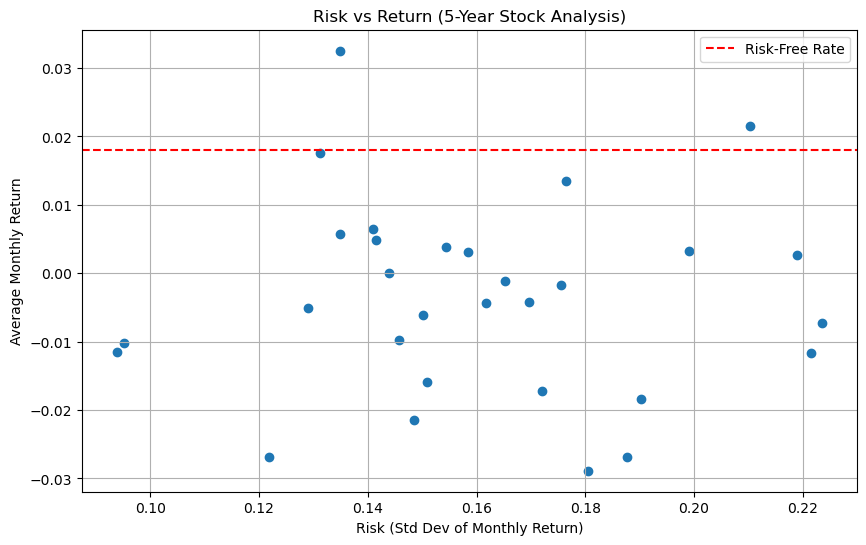

In [139]:
rf = 0.018  # 1.8% monthly

plt.figure(figsize=(10,6))

plt.scatter(
    risk_return['risk'],
    risk_return['avg_return']
)

plt.axhline(rf, color='red', linestyle='--', label='Risk-Free Rate')

plt.xlabel("Risk (Std Dev of Monthly Return)")
plt.ylabel("Average Monthly Return")
plt.title("Risk vs Return (5-Year Stock Analysis)")

plt.legend()
plt.grid(True)
plt.savefig(
    r'C:\Users\MSI\Desktop\TSE_Risk_Return-Analysis\outputs\figures/01_risk_return_scatter.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

هر نقطه نشان‌دهنده یک سهم است که ریسک آن برابر انحراف معیار بازده‌های ماهانه و بازده آن برابر میانگین بازده ماهانه در کل دوره ۵ ساله است✏️
️


3️⃣) Plot the correlation matrix of monthly returns for the 5-year period. (In fact, this matrix
shows how much the monthly return of each stock correlates with the other investigated
stocks over these 5 years.)

📌تبدیل دیتا به فریم مناسب

In [107]:
returns_pivot = monthly_prices.pivot(
    index='Date',
    columns='stock_name',
    values='Monthly_Return'
)

In [108]:
corr_matrix = returns_pivot.corr()

In [109]:
import arabic_reshaper
from bidi.algorithm import get_display

def fa(text):
    return get_display(arabic_reshaper.reshape(text))

In [110]:
corr_fa = corr_matrix.copy()

corr_fa.index = [fa(x) for x in corr_matrix.index]
corr_fa.columns = [fa(x) for x in corr_matrix.columns]

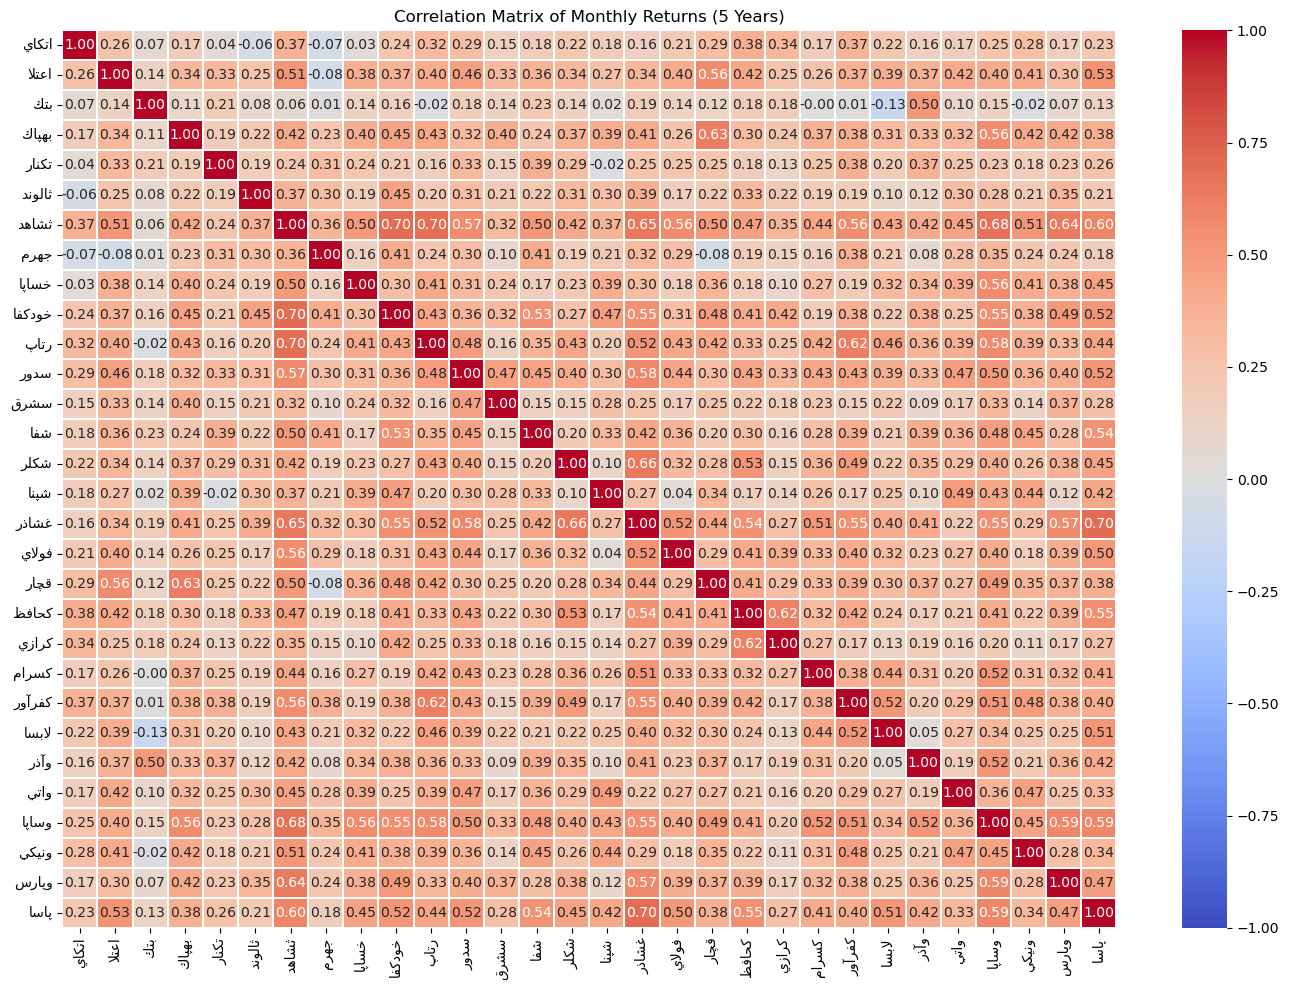

In [140]:
import seaborn as sns


plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_fa,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.2,
    center=0
)

plt.title("Correlation Matrix of Monthly Returns (5 Years)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(
    r'C:\Users\MSI\Desktop\TSE_Risk_Return-Analysis\outputs\figures/02_correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

مقادیر نزدیک به ۱ نشان‌دهنده همبستگی مثبت قوی و مقادیر نزدیک به -۱ نشان‌دهنده همبستگی منفی بین بازده سهام هستند✏️

4️⃣) Calculate the Sharpe ratio for the monthly returns over these 5 years for each of the
investigated stocks, and provide a chart that sorts the stocks based on their Sharpe
ratios. (assumed constant monthly risk-free rate)\
rf = 0.018  # 1.8% monthly 

In [112]:
rf = 0.018 

risk_return['sharpe_ratio'] = (
    risk_return['avg_return'] - rf
) / risk_return['risk']

risk_return.head()

,stock_name,avg_return,risk,sharpe_ratio
0,اتكاي,-0.026889,0.121856,-0.368376
1,اعتلا,-0.015899,0.150965,-0.224551
2,بتك,0.032535,0.134924,0.107728
3,بهپاك,-0.004232,0.169659,-0.131039
4,تكنار,-0.010151,0.095134,-0.295913


In [113]:
sharpe_sorted = risk_return.sort_values(
    by='sharpe_ratio',
    ascending=False
)

sharpe_sorted.head(10)
#مرتب سازی براساس نسبت شارپ

,stock_name,avg_return,risk,sharpe_ratio
2,بتك,0.032535,0.134924,0.107728
26,وساپا,0.021537,0.210366,0.016814
12,سشرق,0.017583,0.131131,-0.003183
21,كسرام,0.013552,0.176448,-0.025211
6,ثشاهد,0.002628,0.218947,-0.070209
14,شكلر,0.003244,0.199132,-0.074102
22,كفرآور,0.006503,0.141038,-0.081519
16,غشاذر,0.005744,0.134943,-0.090820
10,رتاپ,0.003816,0.154289,-0.091929
11,سدور,0.004880,0.141589,-0.092665


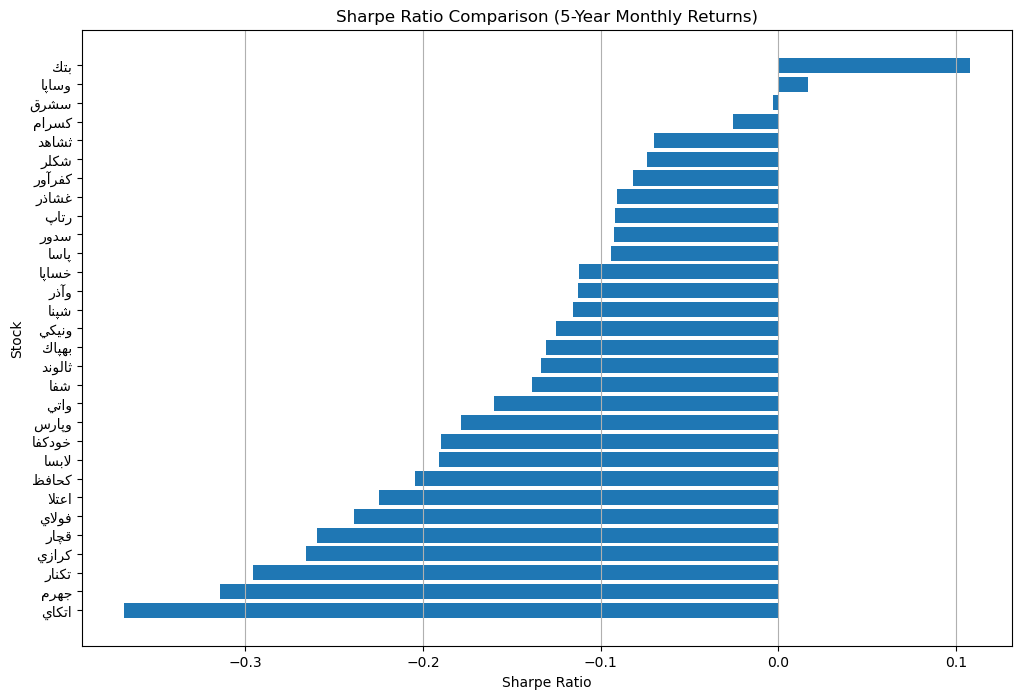

In [142]:


plt.figure(figsize=(12, 8))

plt.barh(
    sharpe_sorted['stock_name'].apply(fa),
    sharpe_sorted['sharpe_ratio']
)

plt.xlabel("Sharpe Ratio")
plt.ylabel("Stock")
plt.title("Sharpe Ratio Comparison (5-Year Monthly Returns)")
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.savefig(
    r'C:\Users\MSI\Desktop\TSE_Risk_Return-Analysis\outputs\figures/03_sharpe_ratio_ranking.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


این نمودار نسبت شارپ هر سهم را بر اساس بازده ماهانه ۵ ساله نشان می‌دهد و سهم‌ها را بر اساس عملکرد تعدیل‌شده نسبت به ریسک مرتب کرده است✏️

5️⃣)Considering the monthly returns over the past 5 years, draw the efficient frontier for these
30 tickers

In [115]:
monthly_prices

,stock_name,Date,AdjClose,Monthly_Return
1,اتكاي,2021-04-30,16680.0,-0.098232
2,اتكاي,2021-05-31,13349.0,-0.199700
3,اتكاي,2021-06-30,10283.0,-0.229680
4,اتكاي,2021-07-31,9300.0,-0.095595
5,اتكاي,2021-08-31,7880.0,-0.152688
...,...,...,...,...
1885,پاسا,2026-01-31,15870.0,-0.118333
1886,پاسا,2026-02-28,14200.0,-0.105230
1887,پاسا,2026-03-31,14200.0,0.000000
1888,پاسا,2026-04-30,14200.0,0.000000


In [116]:
returns = monthly_prices.pivot(
    index='Date',
    columns='stock_name',
    values='Monthly_Return'
)
returns = returns.dropna()
#ماتریس بازده

In [117]:
returns

stock_name,اتكاي,اعتلا,بتك,بهپاك,تكنار,ثالوند,ثشاهد,جهرم,خساپا,خودكفا,...,كرازي,كسرام,كفرآور,لابسا,وآذر,واتي,وساپا,ونيكي,وپارس,پاسا
Date,,,,,,,,,,,,,,,,,,,,,
2021-04-30,-0.098232,-0.188479,0.030840,-0.841566,-0.085156,-0.028313,-0.031144,-0.018059,-0.157676,-0.222728,...,-0.028163,-0.013431,-0.117020,-0.065285,-0.005829,-0.214953,-0.197279,-0.215271,-0.158249,-0.010703
2021-05-31,-0.199700,-0.038756,-0.018231,-0.083441,-0.033561,-0.026231,-0.133840,-0.013793,-0.231527,-0.072293,...,-0.119037,-0.048267,0.008906,-0.098833,-0.098327,-0.115079,-0.134534,-0.083236,0.128800,-0.020866
2021-06-30,-0.229680,-0.047408,0.000000,0.022407,0.014670,-0.036715,0.049258,-0.007576,0.263462,0.020384,...,-0.150810,-0.016905,-0.047675,-0.213946,-0.024519,0.118834,0.248470,0.187980,-0.043232,-0.250197
2021-07-31,-0.095595,0.159690,0.000286,0.134100,-0.116601,-0.036752,-0.090032,-0.056371,-0.135464,-0.106482,...,0.000000,-0.104497,-0.114762,0.039550,-0.142064,0.159319,-0.044118,0.069968,0.022222,0.085263
2021-08-31,-0.152688,-0.008155,0.019709,0.034595,-0.059896,-0.123338,0.110247,-0.057872,0.188380,-0.045374,...,-0.904291,-0.014771,0.055360,0.032497,0.235351,0.072602,0.208205,0.156942,0.105435,0.055286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-31,-0.105977,-0.202611,-0.003376,0.189893,-0.060773,-0.164869,-0.231868,-0.035613,-0.078292,-0.127148,...,-0.121975,-0.082222,-0.195612,-0.164131,-0.203857,-0.125232,-0.155125,-0.069374,-0.195677,-0.118333
2026-02-28,0.045519,0.044876,-0.096528,-0.046332,-0.031373,-0.395018,-0.147353,-0.047267,-0.027027,-0.136483,...,0.012128,-0.046005,0.011364,-0.039690,-0.032821,-0.074655,0.034426,-0.050909,-0.104668,-0.105230
2026-03-31,0.000000,-0.099246,0.000000,0.000000,0.000000,0.000000,0.000000,-0.015504,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [118]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

تشکیل سبدهای بهینه و پیداکردن Efficient Frontier📌

In [119]:
num_portfolios = 500000
results = []

for i in range(num_portfolios):
    
    weights = np.random.random(30) #or number of assets = len(mean_returns)
    weights /= np.sum(weights)

    portfolio_return = np.dot(weights, mean_returns)
    portfolio_risk = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix, weights))
    )

    results.append([portfolio_risk, portfolio_return])

In [120]:
portfolio_df = pd.DataFrame(results, columns=['Risk', 'Return'])

In [121]:
portfolio_df = portfolio_df.sort_values('Risk')

In [122]:
efficient_portfolios = portfolio_df.loc[
    portfolio_df['Return'].cummax() == portfolio_df['Return']
]

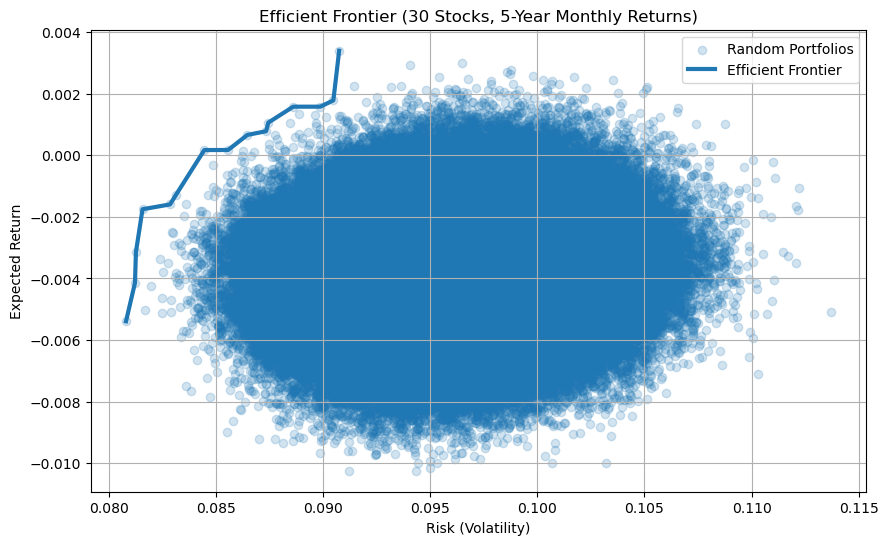

In [143]:
plt.figure(figsize=(10,6))

plt.scatter(
    portfolio_df['Risk'],
    portfolio_df['Return'],
    alpha=0.2,
    label='Random Portfolios'
)

plt.plot(
    efficient_portfolios['Risk'],
    efficient_portfolios['Return'],
    linewidth=3,
    label='Efficient Frontier'
)

plt.xlabel("Risk (Volatility)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier (30 Stocks, 5-Year Monthly Returns)")
plt.legend()
plt.grid(True)
plt.savefig(
    r'C:\Users\MSI\Desktop\TSE_Risk_Return-Analysis\outputs\figures/04_efficient_frontier.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

 این نمودار مجموعه‌ای از پرتفوی‌های ممکن حاصل از ترکیب ۳۰ سهم را نمایش می‌دهد✏️\
 نقاط آبی نشان‌دهنده پرتفوی‌های تصادفی و خط مرزی نشان‌دهنده مرز کارا است که بیشترین بازده مورد انتظار را برای هر سطح ریسک ارائه می‌کند.

6️⃣)Construct an equally weighted index using these 30 stocks to act as a proxy for the
market portfolio. Calculate the Beta (β) of each of the 30 stocks relative to this market
portfolio. Identify the 3 most aggressive stocks (β > 1) and the 3 most defensive stocks
(β < 1)

In [124]:
market_return = returns_pivot.mean(axis=1)
#بازده بازار در هر ماه

In [125]:
market_var = market_return.var() 
#واریانس بازار

In [126]:
betas = {}

for stock in returns_pivot.columns:

    cov = returns_pivot[stock].cov(market_return)

    beta = cov / market_var

    betas[stock] = beta

In [127]:
beta_df = pd.DataFrame(
    betas.items(),
    columns=['stock_name','Beta']
)

دسته بندی براساس بتا📌

In [129]:
aggressive_stocks = (
    beta_df
    .sort_values('Beta', ascending=False)
    .head(3)
)

print("Top 3 Aggressive Stocks")
print(aggressive_stocks)

defensive_stocks = (
    beta_df
    .sort_values('Beta', ascending=True)
    .head(3)
)

print("=== Top 3 Aggressive Stocks ===")
for _, row in aggressive_stocks.iterrows():
    print(f"{row['stock_name']} | Beta = {row['Beta']:.3f}")

print("\n=== Top 3 Defensive Stocks ===")
for _, row in defensive_stocks.iterrows():
    print(f"{row['stock_name']} | Beta = {row['Beta']:.3f}")

Top 3 Aggressive Stocks
   stock_name      Beta
6       ثشاهد  1.948295
26      وساپا  1.761606
24       وآذر  1.287367
=== Top 3 Aggressive Stocks ===
ثشاهد | Beta = 1.948
وساپا | Beta = 1.762
وآذر | Beta = 1.287

=== Top 3 Defensive Stocks ===
بتك | Beta = 0.339
جهرم | Beta = 0.379
تكنار | Beta = 0.419


✏️
با استفاده از شاخص هم‌وزن ساخته‌شده از 30 سهم به عنوان پرتفوی بازار،
بتای هر سهم محاسبه شد. نتایج نشان می‌دهد سهام ثشاهد، وساپا و وآذر
دارای بیشترین بتا بوده و به عنوان سهام تهاجمی شناخته می‌شوند؛
به این معنا که نوسانات آن‌ها از نوسانات بازار بیشتر است
در مقابل، سهام بتك، جهرم و تكنار کمترین بتا را داشته و به عنوان
سهام تدافعی شناخته می‌شوند که حساسیت کمتری نسبت به
تغییرات بازار دارند.

--------------------

In [130]:
monthly_prices.to_csv(
    r'C:\Users\MSI\Desktop\TSE_Risk_Return-Analysis\outputs\tables/monthly_returns.csv',
    index=False,
    encoding='utf-8-sig'
)

In [131]:
cumulative_returns.to_csv(
    r'C:\Users\MSI\Desktop\TSE_Risk_Return-Analysis\outputs\tables/cumulative_returns.csv',
    index=False,
    encoding='utf-8-sig'
)


In [132]:
best_each_month.to_csv(
    r'C:\Users\MSI\Desktop\TSE_Risk_Return-Analysis\outputs\tables/best_stock_each_month.csv',
    index=False,
    encoding='utf-8-sig'
)

In [133]:
worst_each_month.to_csv(
    r'C:\Users\MSI\Desktop\TSE_Risk_Return-Analysis\outputs\tables/worst_stock_each_month.csv',
    index=False,
    encoding='utf-8-sig'
)

In [134]:
risk_return.to_csv(
    r'C:\Users\MSI\Desktop\TSE_Risk_Return-Analysis\outputs\tables/risk_return.csv',
    index=False,
    encoding='utf-8-sig'
)

In [136]:
beta_df.to_csv(
    r'C:\Users\MSI\Desktop\TSE_Risk_Return-Analysis\outputs\tables/beta_summary.csv',
    index=False,
    encoding='utf-8-sig'
)